In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Adjust path if your CSV files are in app/data/:
df = pd.read_csv("../app/data/kenya.csv")
# If you moved CSVs to project root, use: df = pd.read_csv("kenya.csv")
df['Country'] = 'Kenya'
print("Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../app/data/kenya.csv'

In [3]:
# Adjust path if your CSV files are in app/data/:
df = pd.read_csv("../data/kenya.csv")
# If you moved CSVs to project root, use: df = pd.read_csv("kenya.csv")
df['Country'] = 'Kenya'
print("Shape:", df.shape)
df.head()

Shape: (4108, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


In [4]:
df = df.replace(-999, np.nan)
print("Missing values per column:\n", df.isna().sum())

Missing values per column:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [5]:
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
print("Date range:", df['Date'].min(), "to", df['Date'].max())
df[['YEAR','DOY','Date']].head()

Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,Date
0,2015,1,2015-01-01
1,2015,2,2015-01-02
2,2015,3,2015-01-03
3,2015,4,2015-01-04
4,2015,5,2015-01-05


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicate rows: 0


In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046,3.248907


In [8]:
weather_cols = ['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M']
df[weather_cols] = df[weather_cols].ffill().fillna(df[weather_cols].median())
print("Missing after cleaning:", df.isna().sum().sum())

Missing after cleaning: 0


In [9]:
from scipy import stats
cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
z = np.abs(stats.zscore(df[cols].dropna()))
outliers = (z > 3).any(axis=1)
print(f"Rows with |Z|>3: {outliers.sum()}")

Rows with |Z|>3: 121


In [10]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/kenya_clean.csv', index=False)
print("Saved to data/kenya_clean.csv")

Saved to data/kenya_clean.csv


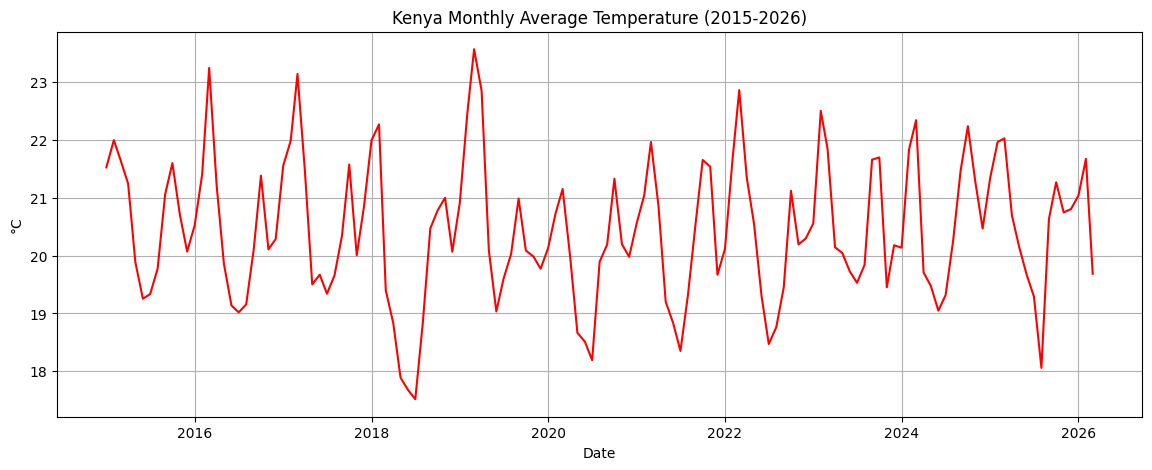

In [11]:
monthly = df.groupby(['Year','Month'])['T2M'].mean().reset_index()
monthly['Date'] = pd.to_datetime(monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str))
plt.figure(figsize=(14,5))
plt.plot(monthly['Date'], monthly['T2M'], color='red')
plt.title('Kenya Monthly Average Temperature (2015-2026)')
plt.xlabel('Date'); plt.ylabel('°C')
plt.grid(True)
plt.show()

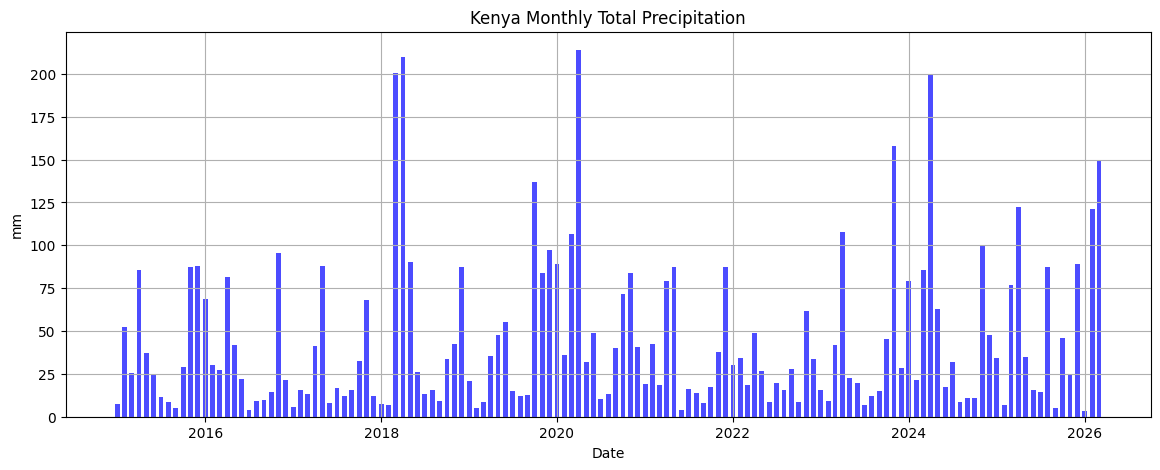

In [12]:
precip = df.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()
precip['Date'] = pd.to_datetime(precip['Year'].astype(str) + '-' + precip['Month'].astype(str))
plt.figure(figsize=(14,5))
plt.bar(precip['Date'], precip['PRECTOTCORR'], width=20, color='blue', alpha=0.7)
plt.title('Kenya Monthly Total Precipitation')
plt.xlabel('Date'); plt.ylabel('mm')
plt.grid(True)
plt.show()

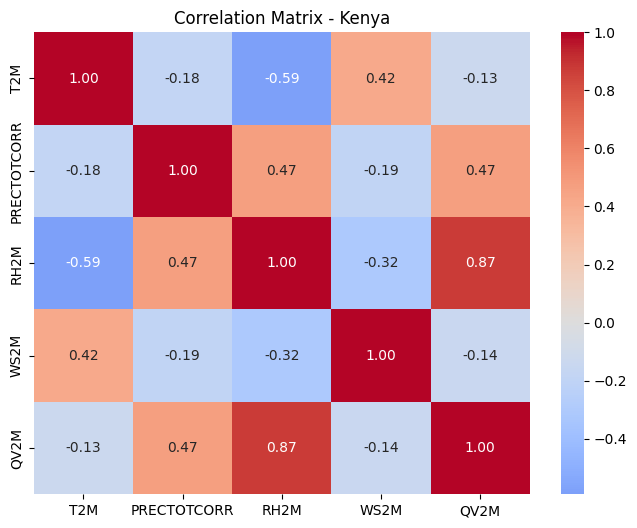

In [13]:
corr = df[['T2M','PRECTOTCORR','RH2M','WS2M','QV2M']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Kenya')
plt.show()

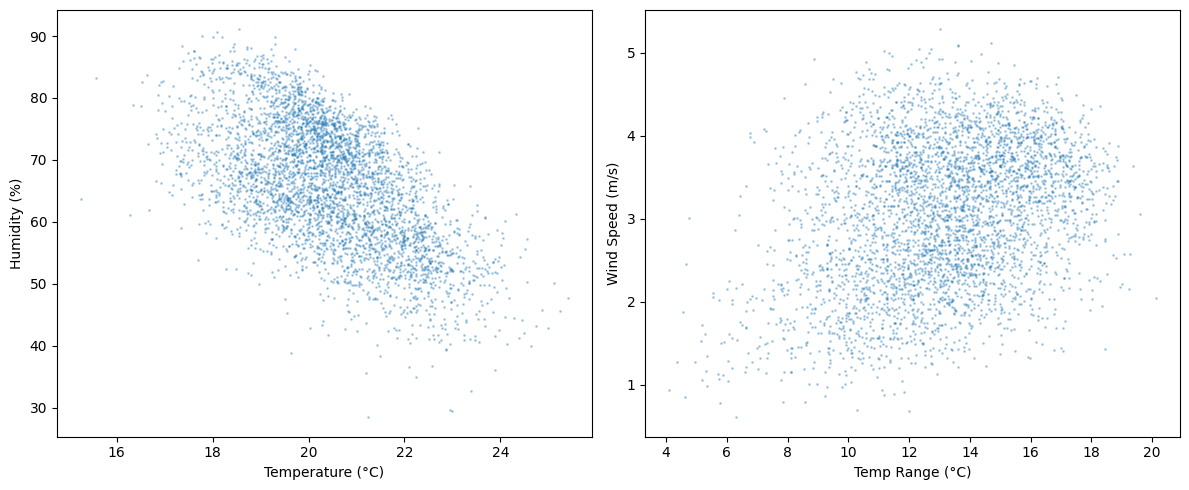

In [14]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
axes[0].set_xlabel('Temperature (°C)'); axes[0].set_ylabel('Humidity (%)')
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
axes[1].set_xlabel('Temp Range (°C)'); axes[1].set_ylabel('Wind Speed (m/s)')
plt.tight_layout()
plt.show()

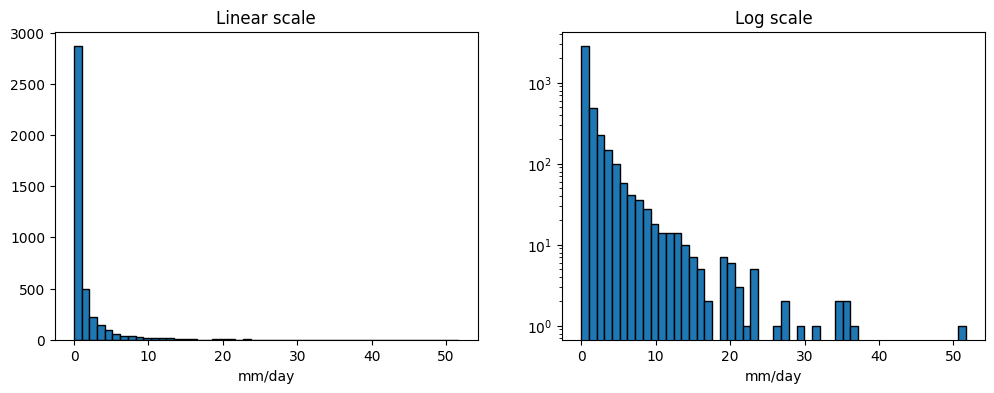

In [15]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
axes[0].set_title('Linear scale')
axes[0].set_xlabel('mm/day')
axes[1].hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Log scale')
axes[1].set_xlabel('mm/day')
plt.show()

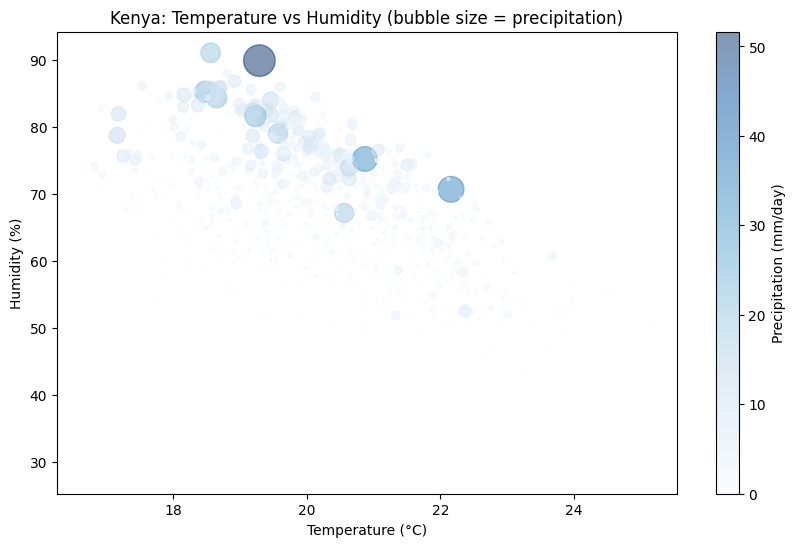

In [16]:
sample = df.sample(min(1000, len(df)))
plt.figure(figsize=(10,6))
sc = plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5, c=sample['PRECTOTCORR'], cmap='Blues')
plt.colorbar(sc, label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)'); plt.ylabel('Humidity (%)')
plt.title('Kenya: Temperature vs Humidity (bubble size = precipitation)')
plt.show()